# 4.7) Árvores de decisão

In [1]:
from sklearn.tree import DecisionTreeClassifier


##### Base de risco de crédito, mais simples:

In [2]:
# coletar o arquivo anteriormente salvo 
import pickle
# rb leitura
with open('../4-Bayesiana/risco_credito.pkl','rb') as f:
      X_risco_credito, y_risco_credito = pickle.load(f)

base de dados na aula teórica

aplicação do labelencoder

atributos: colunas

Histórico de cŕedito, dívidas, garantias e a renda

In [3]:
X_risco_credito

array([[2, 0, 1, 0],
       [1, 0, 1, 1],
       [1, 1, 1, 1],
       [1, 1, 1, 2],
       [1, 1, 1, 2],
       [1, 1, 0, 2],
       [2, 1, 1, 0],
       [2, 1, 0, 2],
       [0, 1, 1, 2],
       [0, 0, 0, 2],
       [0, 0, 1, 0],
       [0, 0, 1, 1],
       [0, 0, 1, 2],
       [2, 0, 1, 1]], dtype=object)

previsão, risco de créditos (y)

In [4]:
y_risco_credito

array(['alto', 'alto', 'moderado', 'alto', 'baixo', 'baixo', 'alto',
       'moderado', 'baixo', 'baixo', 'alto', 'moderado', 'baixo', 'alto'],
      dtype=object)

In [9]:
print('Risco de crédito : {} '.format(set(y_risco_credito)))

Risco de crédito : {'alto', 'baixo', 'moderado'} 


https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

class sklearn.tree.DecisionTreeClassifier(*, criterion='gini', splitter='best', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=None, random_state=None, max_leaf_nodes=None, min_impurity_decrease=0.0, class_weight=None, ccp_alpha=0.0, monotonic_cst=None)

Colocar como entropy :

criterion{“gini”, “entropy”, “log_loss”}, default=”gini”

The function to measure the quality of a split. Supported criteria are “gini” for the Gini impurity and “log_loss” and “entropy” both for the Shannon information gain, see Mathematical formulation.





In [10]:
# será gerado a árvore de decisão
arvore_risco_credito = DecisionTreeClassifier(criterion ='entropy')
# atributo previsão X_risco_credito
# classe y_risco_credito
arvore_risco_credito.fit(X_risco_credito,y_risco_credito) # treinamento concluido

DecisionTreeClassifier(criterion='entropy')

In [13]:
# split é divisão da árvore, no caso para 2
print(arvore_risco_credito.get_params())


{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}


In [12]:
print(arvore_risco_credito)

DecisionTreeClassifier(criterion='entropy')


In [14]:
# podemos retornar o feat import  e imprime os atributos, 
# codificações adicionas -> cálculo do ganho de informação, que no caso é o da renda
arvore_risco_credito.feature_importances_

array([0.3362078 , 0.14179499, 0.03885431, 0.4831429 ])

ver a importância de cada atributo, ou seja, o atributo que possui o maior ganho de informação. 

No exemplo temos 4 atributos e o que tem a maior importância é a úttima, com 48,3% (que equivale a renda), o segundo com 33,6% sendo a história do crédito, a dívida a terceira, com 14,2% e a última a garantia, com 3,9%; 

In [18]:
import pandas as pd
base_risco_credito = pd.read_csv('../4-Bayesiana/risco_credito.csv')
base_risco_credito

,historia,divida,garantias,renda,risco
0,ruim,alta,nenhuma,0_15,alto
1,desconhecida,alta,nenhuma,15_35,alto
2,desconhecida,baixa,nenhuma,15_35,moderado
3,desconhecida,baixa,nenhuma,acima_35,alto
4,desconhecida,baixa,nenhuma,acima_35,baixo
5,desconhecida,baixa,adequada,acima_35,baixo
6,ruim,baixa,nenhuma,0_15,alto
7,ruim,baixa,adequada,acima_35,moderado
8,boa,baixa,nenhuma,acima_35,baixo
9,boa,alta,adequada,acima_35,baixo


Visualizar a árvore de decisão

[Text(0.5, 0.9, 'x[3] <= 1.5\nentropy = 1.531\nsamples = 14\nvalue = [6, 5, 3]'),
 Text(0.2, 0.7, 'x[3] <= 0.5\nentropy = 0.863\nsamples = 7\nvalue = [5, 0, 2]'),
 Text(0.35, 0.8, 'True  '),
 Text(0.1, 0.5, 'entropy = 0.0\nsamples = 3\nvalue = [3, 0, 0]'),
 Text(0.3, 0.5, 'x[0] <= 0.5\nentropy = 1.0\nsamples = 4\nvalue = [2, 0, 2]'),
 Text(0.2, 0.3, 'entropy = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.4, 0.3, 'x[1] <= 0.5\nentropy = 0.918\nsamples = 3\nvalue = [2, 0, 1]'),
 Text(0.3, 0.1, 'entropy = 0.0\nsamples = 2\nvalue = [2, 0, 0]'),
 Text(0.5, 0.1, 'entropy = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.8, 0.7, 'x[0] <= 1.5\nentropy = 1.149\nsamples = 7\nvalue = [1, 5, 1]'),
 Text(0.65, 0.8, '  False'),
 Text(0.7, 0.5, 'x[0] <= 0.5\nentropy = 0.65\nsamples = 6\nvalue = [1, 5, 0]'),
 Text(0.6, 0.3, 'entropy = 0.0\nsamples = 3\nvalue = [0, 3, 0]'),
 Text(0.8, 0.3, 'x[2] <= 0.5\nentropy = 0.918\nsamples = 3\nvalue = [1, 2, 0]'),
 Text(0.7, 0.1, 'entropy = 0.0\nsamples = 1\nval

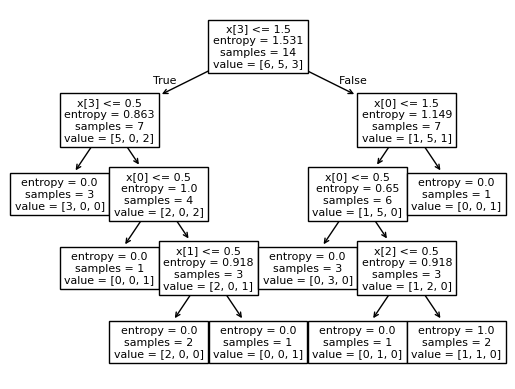

In [19]:
from sklearn import tree

tree.plot_tree(arvore_risco_credito)


In [20]:
arvore_risco_credito.feature_importances_

array([0.3362078 , 0.14179499, 0.03885431, 0.4831429 ])

x[3] que é a renda com 48,3%

In [21]:
lista_previsao = list(base_risco_credito.columns)
lista_previsao

['historia', 'divida', 'garantias', 'renda', 'risco']

In [23]:
lista_previsao = lista_previsao[:-1]
lista_previsao

['historia', 'divida', 'garantias', 'renda']

[Text(0.5, 0.9, 'renda <= 1.5\nentropy = 1.531\nsamples = 14\nvalue = [6, 5, 3]'),
 Text(0.2, 0.7, 'renda <= 0.5\nentropy = 0.863\nsamples = 7\nvalue = [5, 0, 2]'),
 Text(0.35, 0.8, 'True  '),
 Text(0.1, 0.5, 'entropy = 0.0\nsamples = 3\nvalue = [3, 0, 0]'),
 Text(0.3, 0.5, 'historia <= 0.5\nentropy = 1.0\nsamples = 4\nvalue = [2, 0, 2]'),
 Text(0.2, 0.3, 'entropy = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.4, 0.3, 'divida <= 0.5\nentropy = 0.918\nsamples = 3\nvalue = [2, 0, 1]'),
 Text(0.3, 0.1, 'entropy = 0.0\nsamples = 2\nvalue = [2, 0, 0]'),
 Text(0.5, 0.1, 'entropy = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.8, 0.7, 'historia <= 1.5\nentropy = 1.149\nsamples = 7\nvalue = [1, 5, 1]'),
 Text(0.65, 0.8, '  False'),
 Text(0.7, 0.5, 'historia <= 0.5\nentropy = 0.65\nsamples = 6\nvalue = [1, 5, 0]'),
 Text(0.6, 0.3, 'entropy = 0.0\nsamples = 3\nvalue = [0, 3, 0]'),
 Text(0.8, 0.3, 'garantias <= 0.5\nentropy = 0.918\nsamples = 3\nvalue = [1, 2, 0]'),
 Text(0.7, 0.1, 'entropy = 

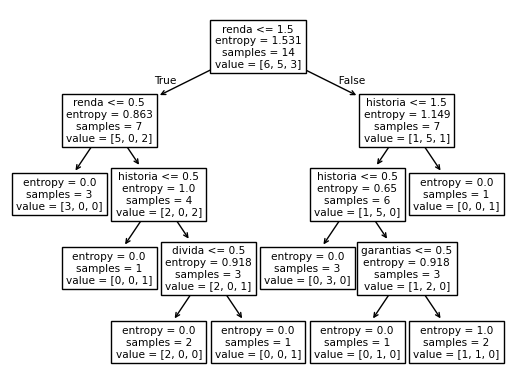

In [27]:
# colocar em forma de lista de deixar mais legível

from sklearn import tree

tree.plot_tree(arvore_risco_credito,feature_names = lista_previsao) # associar a nova variável

[Text(0.5, 0.9, 'renda <= 1.5\nentropy = 1.531\nsamples = 14\nvalue = [6, 5, 3]'),
 Text(0.2, 0.7, 'renda <= 0.5\nentropy = 0.863\nsamples = 7\nvalue = [5, 0, 2]'),
 Text(0.35, 0.8, 'True  '),
 Text(0.1, 0.5, 'entropy = 0.0\nsamples = 3\nvalue = [3, 0, 0]'),
 Text(0.3, 0.5, 'historia <= 0.5\nentropy = 1.0\nsamples = 4\nvalue = [2, 0, 2]'),
 Text(0.2, 0.3, 'entropy = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.4, 0.3, 'divida <= 0.5\nentropy = 0.918\nsamples = 3\nvalue = [2, 0, 1]'),
 Text(0.3, 0.1, 'entropy = 0.0\nsamples = 2\nvalue = [2, 0, 0]'),
 Text(0.5, 0.1, 'entropy = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.8, 0.7, 'historia <= 1.5\nentropy = 1.149\nsamples = 7\nvalue = [1, 5, 1]'),
 Text(0.65, 0.8, '  False'),
 Text(0.7, 0.5, 'historia <= 0.5\nentropy = 0.65\nsamples = 6\nvalue = [1, 5, 0]'),
 Text(0.6, 0.3, 'entropy = 0.0\nsamples = 3\nvalue = [0, 3, 0]'),
 Text(0.8, 0.3, 'garantias <= 0.5\nentropy = 0.918\nsamples = 3\nvalue = [1, 2, 0]'),
 Text(0.7, 0.1, 'entropy = 

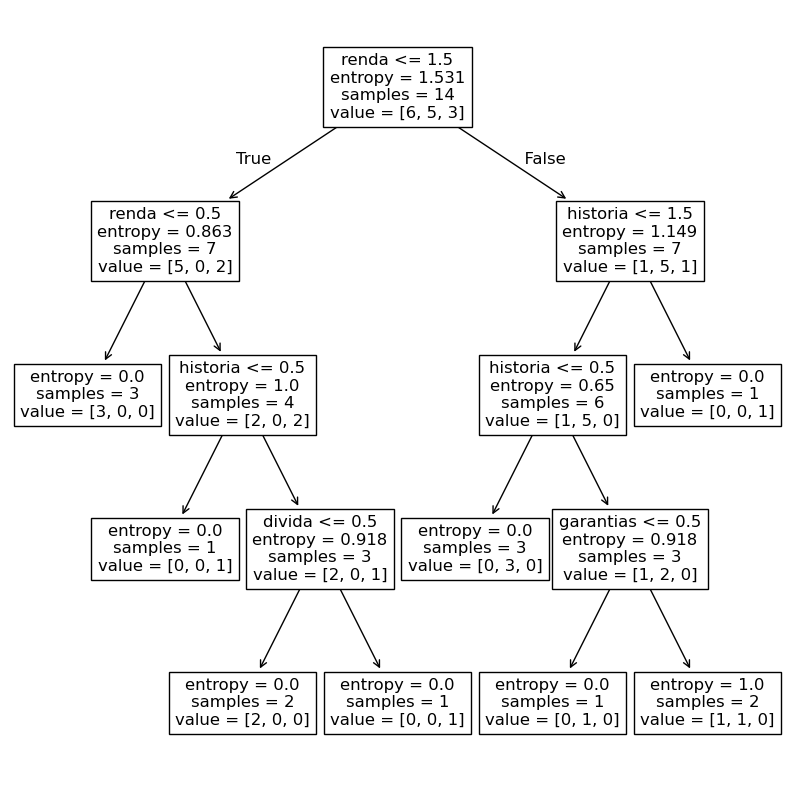

In [29]:
import matplotlib.pyplot as plt

figura, eixos = plt.subplots(nrows=1, ncols=1, figsize=(10,10)) # (1 linha,1 coluna)

tree.plot_tree(arvore_risco_credito,feature_names = lista_previsao) # associar a nova variável

podemos também adicionar os valores das classes

no final temos a previsão se é alto moderado ou baixo, depois do values

passar o parâmetro adicional

In [30]:
arvore_risco_credito.classes_

array(['alto', 'baixo', 'moderado'], dtype=object)

[Text(0.5, 0.9, 'renda <= 1.5\nentropy = 1.531\nsamples = 14\nvalue = [6, 5, 3]\nclass = alto'),
 Text(0.2, 0.7, 'renda <= 0.5\nentropy = 0.863\nsamples = 7\nvalue = [5, 0, 2]\nclass = alto'),
 Text(0.35, 0.8, 'True  '),
 Text(0.1, 0.5, 'entropy = 0.0\nsamples = 3\nvalue = [3, 0, 0]\nclass = alto'),
 Text(0.3, 0.5, 'historia <= 0.5\nentropy = 1.0\nsamples = 4\nvalue = [2, 0, 2]\nclass = alto'),
 Text(0.2, 0.3, 'entropy = 0.0\nsamples = 1\nvalue = [0, 0, 1]\nclass = moderado'),
 Text(0.4, 0.3, 'divida <= 0.5\nentropy = 0.918\nsamples = 3\nvalue = [2, 0, 1]\nclass = alto'),
 Text(0.3, 0.1, 'entropy = 0.0\nsamples = 2\nvalue = [2, 0, 0]\nclass = alto'),
 Text(0.5, 0.1, 'entropy = 0.0\nsamples = 1\nvalue = [0, 0, 1]\nclass = moderado'),
 Text(0.8, 0.7, 'historia <= 1.5\nentropy = 1.149\nsamples = 7\nvalue = [1, 5, 1]\nclass = baixo'),
 Text(0.65, 0.8, '  False'),
 Text(0.7, 0.5, 'historia <= 0.5\nentropy = 0.65\nsamples = 6\nvalue = [1, 5, 0]\nclass = baixo'),
 Text(0.6, 0.3, 'entropy = 0.

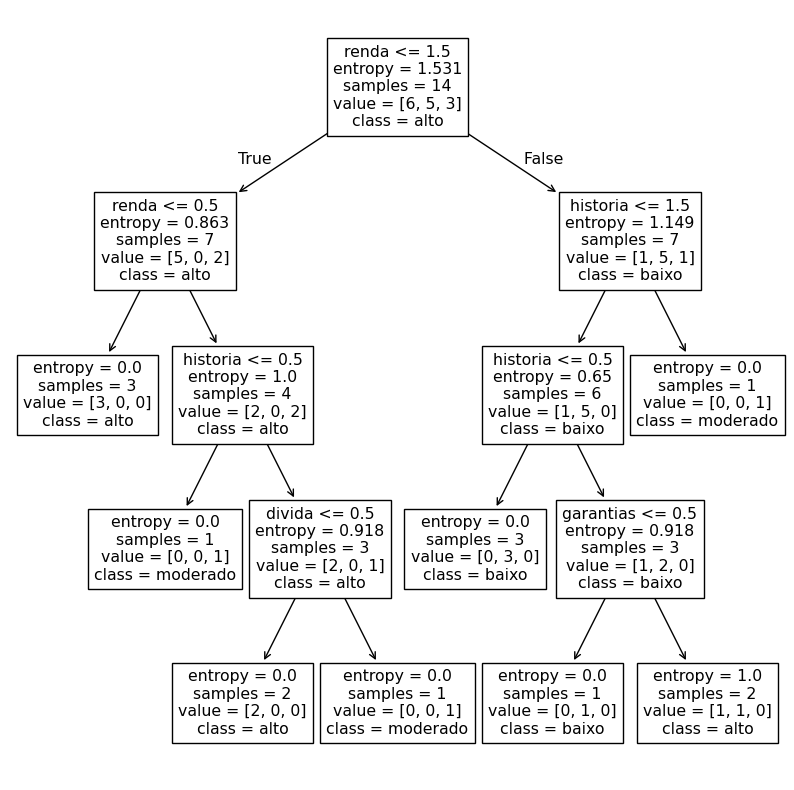

In [31]:
figura, eixos = plt.subplots(nrows=1, ncols=1, figsize=(10,10)) # (1 linha,1 coluna)

tree.plot_tree(arvore_risco_credito,feature_names = lista_previsao,class_names = arvore_risco_credito.classes_) # associar a nova variável

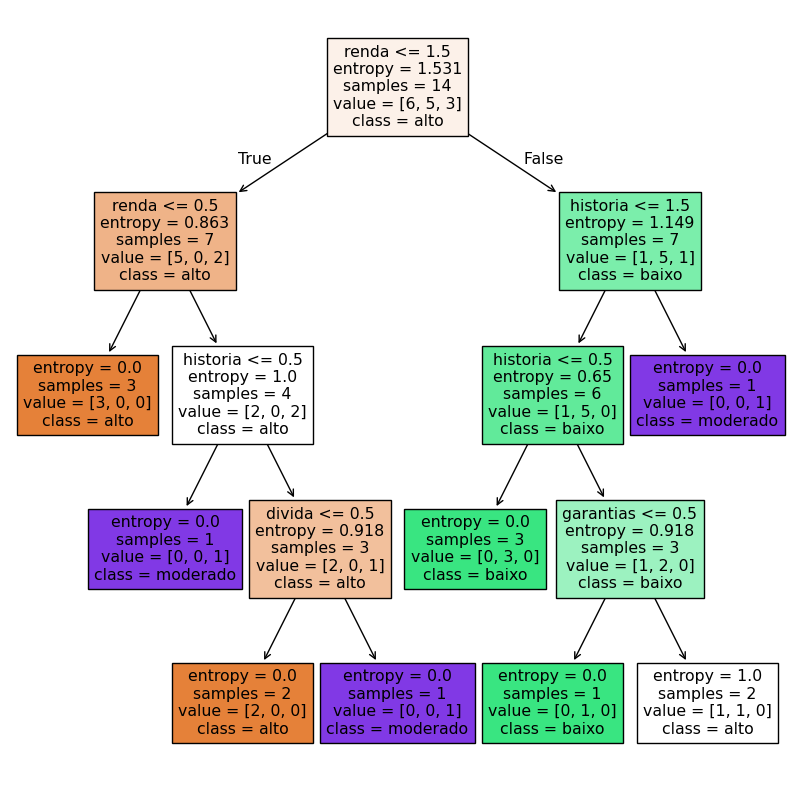

In [32]:
figura, eixos = plt.subplots(nrows=1, ncols=1, figsize=(10,10)) # (1 linha,1 coluna)

tree.plot_tree(arvore_risco_credito,feature_names = lista_previsao,class_names = arvore_risco_credito.classes_, filled=True);
# ; não aparecerá o texto e o fill fará o preenchimento da árvore. 

# a entropia de 1,53 foi o mesmo achado no cálculo manual da renda

Árvore mais clara

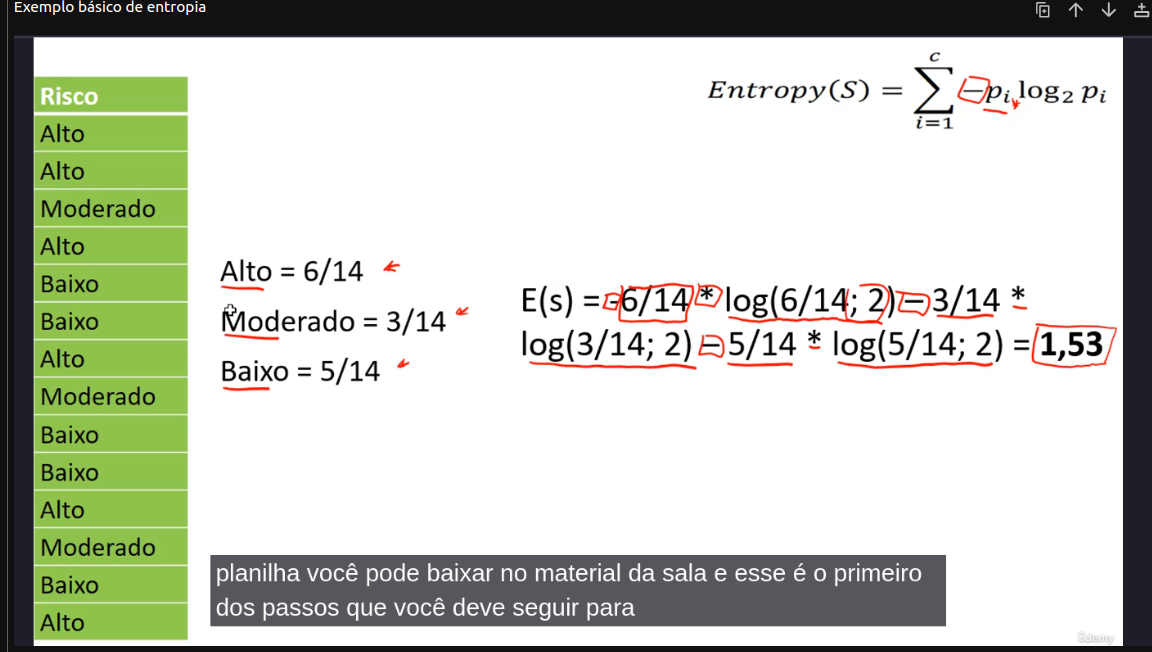


Colar os registros 

- história boa, dívida alta, garantias nenhuma, renda >35

- história ruim, dívida alta, garantias adequada, renda < 15

In [33]:
# ver a previsão

# colar a previsão de uma matriz, passaremos o enconder
# mesmo do algoritmo naive bayes ****
# história boa (0), dívida alta (0), garantias nenhuma (1), renda > 35 (2)
# história ruim (2), dívida alta (0), garantias adequada (0), renda < 15 (0)
previsoes = arvore_risco_credito.predict([ [0,0,1,2], [2,0,0,0]  ])

In [34]:
previsoes

array(['baixo', 'alto'], dtype=object)

previsões dos dois clientes, uma o risco é baixo e o outro é risco alto de ter impréstimo

### ['historia', 'divida', 'garantias', 'renda']

percorrer a árvore:
[0,0,1,2]

2 renda -> false

0 historia -> true

0 historia -> true

baixo


#### ['historia', 'divida', 'garantias', 'renda']

 true sempre a esquerda
percorrer a árvore:
[2,0,0,0] 

0 renda -> true

0 renda -> true

alto risco